# Spectral analysis of phase-contrast movies

This program loads images processed from Fiji and calculates average spectra.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 16/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


In [1]:
# core functions for image handling and plotting
#from pySciCam.pySciCam import ImageSequence # https://github.com/djorlando24/pySciCam

from PIL import Image
import numpy as np
import os
from tqdm.notebook import tqdm
from scipy.signal import welch
from joblib import Parallel, delayed

In [2]:
import matplotlib.pyplot as plt
%matplotlib widget

In [3]:
def read_multipage_tiff(path):
    """
    Reads a multipage-tiff file and returns a list of frames as NumPy arrays.
    """
    img = Image.open(path)
    images = []
    for i in range(img.n_frames):
        img.seek(i)
        # Convert the current frame to a NumPy array
        frame_array = np.array(img)
        images.append(frame_array)
    
    # The file handle is automatically closed by the context manager 
    # if you use 'with Image.open(...) as img:'
    # However, for multi-frame images, the file is left open until close() is called or the program ends.
    # Using 'with' helps ensure it's closed properly.
    return images

In [4]:
file_path = '/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-1-CavitationNozzleImaging/Processed_2026/8bitBkDiv_NozzleA_10bar_.5bar_45deg_y-13.3.tif'
#file_path = '/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-1-CavitationNozzleImaging/Processed_2026/8bitBkDiv_NozzleA_10bar_1bar_45deg_y-13.3.tif'

descr = os.path.basename(file_path)
fs=2000. # fps

# flow conditions
p1=10e5
p2=0.5e5 #1.0e5 #
d=0.5e-3
rhol=850

In [5]:
# Read in images    
frames_list = read_multipage_tiff(file_path)

print(f"Total frames read: {len(frames_list)}")
print(f"Shape of the first frame: {frames_list[0].shape}")

Total frames read: 2670
Shape of the first frame: (750, 400)


In [6]:
# Convert list into ndarray
frames_array=np.dstack(frames_list)
del frames_list

In [7]:
# Apply cropping?
frames_array = frames_array[0:720,:]

In [8]:
# Compute stats
averageImage = np.nanmean(frames_array,axis=-1)
stdImage = np.nanstd(frames_array,axis=-1)

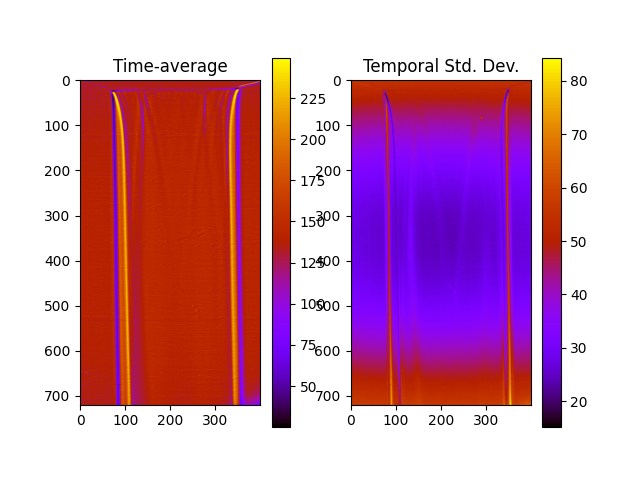

In [9]:
# Plot test figures
fig=plt.figure()
ax=fig.add_subplot(121)
h=ax.imshow(averageImage,cmap='gnuplot')
plt.title("Time-average")
plt.colorbar(h)
ax=fig.add_subplot(122)
h=ax.imshow(stdImage,cmap='gnuplot')
plt.title("Temporal Std. Dev.")
plt.colorbar(h);

## Spectral analysis

Pixelwise welch method and post average

In [10]:
print("Size of data:",frames_array.shape)

Size of data: (720, 400, 2670)


In [11]:
nperseg=512 # output is half this

#welch_output = np.zeros((frames_array.shape[0],frames_array.shape[1], int(nperseg/2 + 1)))

# Computation of per-pixel spectra
def welch_fun(xx): #noverlap=int(nperseg * (3/4))
    return welch(xx, fs, nperseg=nperseg,\
                 detrend='linear', return_onesided=True,\
                 scaling='density')
    
def welch_vector(x):
    welch_output = np.zeros((x.shape[0], int(nperseg/2 + 1)))
    for j in range(x.shape[0]):
        f, Pxx = welch_fun(x[j,:])
        welch_output[j,:] = Pxx
    return welch_output

print("n=",frames_array.shape[0])

n= 720


### Run analysis in parallel on each row of pixels

In [ ]:
all_output = Parallel(n_jobs=-1, verbose=10)\
    (delayed(welch_vector)(frames_array[i,...]) for i in range(frames_array.shape[0]))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.0s


In [ ]:
# Get freq
f, Pxx = welch_fun(frames_array[0,0,:])

# Convert output of above function into 3d ndarray
Pxx = np.dstack(all_output)
Pxx = np.rollaxis(Pxx,2,0)
print(Pxx.shape)

### Save result

In [ ]:
output_dir = os.path.dirname(file_path)+'/'+os.path.splitext(os.path.basename(file_path))[0]
os.mkdir(output_dir)
npy_path=output_dir+'_spectra.npz'
np.savez(npy_path, freq=f, spectra=Pxx)
print("Wrote %i bytes" % os.path.getsize(npy_path))


## Spatially-average spectrum

Include all pixels.

In [ ]:
# Calculate strouhal number
A = (np.pi/4.)*(d**2)
K = (p1-0)/(p1-p2)

mdot = 0.611 * np.sqrt(K) * A * np.sqrt(2*rhol*(p1-p2))
Ubar = mdot / (rhol*A)
print("Ubar = %f m/s" % Ubar)

###
Str = f*d/Ubar

In [ ]:
meanSpectrum=np.nanmean(Pxx,axis=(0,1))
stdSpectrum=np.nanstd(Pxx,axis=(0,1))

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
plt.grid(alpha=.2)
p1,=ax.plot(f, meanSpectrum)
plt.xlabel("Frequency [Hz]");
plt.ylabel("Power spectral density [1/Hz]");
ax2=ax.twiny()
p2,=ax2.plot(Str, stdSpectrum,ls='--',lw=1)
plt.xlabel("Strouhal number");
ax.set_xscale('log'); ax2.set_xscale('log')

# Find peaks, and remove those that overlap too much
top_indices = np.argpartition(-meanSpectrum, 6)[:6]

bw = 10. # Hz
bw_frac = 0.1
def bracket_freq(fcent):
    fmin=np.round(fcent*(1-bw_frac)-bw,1)
    fmax=np.round(fcent*(1+bw_frac)+bw,1);
    if(fmin<0): fmin=0
    if(fmax>max(f)): fmax=max(f)
    return fmin, fmax


indices=[top_indices[0]]
for i in top_indices[1:]:
    fcent=f[i]
    fmin, fmax = bracket_freq(fcent)
    overlapping = np.any([ (f[j]>fmin) & (f[j]<fmax) for j in indices ])
    if not overlapping: indices.append(i)

p3=ax.scatter(f[indices],meanSpectrum[indices],c='r');
plt.legend([p1,p2,p3],["Mean spectrum","RMS spectrum","Peaks"])
plt.savefig(output_dir+"/spatial_average_spectrum.pdf");

## Map frequency peaks

In [ ]:
for fcent in f[indices]:
    fmin, fmax = bracket_freq(fcent)
        
    fbin = np.where((f>=fmin) & (f<=fmax))[0]

    # Integral of part of spectrum in frequency range
    Pxx_bin = np.zeros((Pxx.shape[0],Pxx.shape[1]))
    for b in fbin:
        Pxx_bin += Pxx[...,b]
    Pxx_bin /= float(len(fbin))

    # Spectrum of pixels where integral is above threshold
    thr = np.nanmean(Pxx_bin) + 2*np.nanstd(Pxx_bin)
    meanSpectrumConditional=np.nanmean(Pxx[Pxx_bin>thr,:],axis=0)
    
    fig=plt.figure()
    ax=fig.add_subplot(121)
    h=ax.imshow(Pxx_bin,cmap='gnuplot')
    plt.colorbar(h);
    
    ax=fig.add_subplot(122)
    plt.grid(alpha=.2)
    ax.loglog(f, meanSpectrumConditional)
    if len(fbin)<2: fbin = np.hstack(( fbin[0]-1, fbin, fbin[-1]+2 ))
    ax.fill_between(f[fbin],0*meanSpectrumConditional[fbin],meanSpectrumConditional[fbin],alpha=.25)
    plt.xlabel("Freq [Hz]")
    plt.ylabel("Power spectral density [1/Hz]");
    plt.xlim(1,1e3)
    ax2=ax.twiny()
    plt.xlim(1*d/Ubar, 1e3*d/Ubar)
    #ax2.loglog(Str,meanSpectrumConditional)
    plt.xlabel("Strouhal Number")
    
    plt.suptitle("f = %g - %g Hz" % (fmin,fmax))

    plt.tight_layout();
    plt.savefig(output_dir+"/bracketing_f%fHz.pdf" % fcent);